# Chapter 1.1. 아주 짧은 역사와 이번 학기 로드맵 — 실습 노트북

[![Open In Colab: Timeline](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/SuminHan/book-ml/blob/main/notebooks/ml1/chapter01_1_timeline.ipynb)

책 본문: [1.1 아주 짧은 역사와 이번 학기 로드맵](https://smhanlab.com/book-ml/kor/ml1/chapter01.html)

이 노트북은 1.1절의 세 가지를 코드로 직접 확인합니다:
(1) 본문의 연표(1943~2025)에서 "사건 사이의 실제 간격"을 계산하고 시각화하며,
(2) "1969년의 XOR 증명 → 1986년 역전파"로 이어진 첫 AI 겨울의 17년을 눈으로 보고,
(3) 이 책의 도구 표(NumPy, Matplotlib, pandas, scikit-learn, PyTorch)가 이 환경에서
실제로 import되는지 점검합니다 — 본문 실습의 "도구 점검"을 코드 그대로 보여주는 것이
이 노트북의 역할입니다.


## 1. 연표의 "간격" 계산

본문 연표에 있는 사건들을 (연도, 이름) 튜플로 입력하고, 연속 사건 사이의
**실제 연도 차**를 계산합니다. 연표를 위에서 아래로 읽을 때는 모든 사건이
"다음 줄"이라 비슷하게 보이지만, 이 간격 계산이 "역사가 직선이 아니다"는
말의 구체적 의미입니다 — 어떤 사건 사이는 26년, 어떤 사이는 5년입니다.


In [1]:
import numpy as np

# 본문 연표(1943~2025) 그대로
events = [
    (1943, "M-P 신경원 모형"),
    (1969, "XOR 증명 → 첫 AI 겨울"),
    (1986, "역전파 재발견"),
    (1998, "LeNet (CNN)"),
    (2012, "AlexNet (ImageNet)"),
    (2017, "Transformer"),
    (2022, "ChatGPT"),
    (2025, "멀티모달 LLM"),
]

gaps = np.diff([y for y, _ in events])
for (y1, n1), (y2, n2), g in zip(events, events[1:], gaps):
    print(f"{y1} {n1}  →  {y2} {n2}   :  {int(g)}년")
print()
print(f"가장 긴 간격: {int(gaps.max())}년, 가장 짧은 간격: {int(gaps.min())}년")
print(f"전체 기간: {events[-1][0] - events[0][0]}년")
assert gaps.max() == 26 and gaps.min() == 3
assert (gaps == 17).sum() == 1   # 1969→1986: 첫 AI 겨울


1943 M-P 신경원 모형  →  1969 XOR 증명 → 첫 AI 겨울   :  26년
1969 XOR 증명 → 첫 AI 겨울  →  1986 역전파 재발견   :  17년
1986 역전파 재발견  →  1998 LeNet (CNN)   :  12년
1998 LeNet (CNN)  →  2012 AlexNet (ImageNet)   :  14년
2012 AlexNet (ImageNet)  →  2017 Transformer   :  5년
2017 Transformer  →  2022 ChatGPT   :  5년
2022 ChatGPT  →  2025 멀티모달 LLM   :  3년

가장 긴 간격: 26년, 가장 짧은 간격: 3년
전체 기간: 82년


## 2. "겨울"을 시각화 — 사건을 연도 축 위에 놓으면

같은 사건들을 **연도 축 위에 위치**로 그립니다. 표로 볼 때는 10개의 행이
균일해 보였는데, 그래프로 보면 1969~1986(첫 AI 겨울)과 2012년 이후가
비롯하는 "간격의 비대칭"이 바로 보입니다 — 역사의 상당 부분이 침체였고,
데이터·계산의 두 축이 갖춰진 2012년 이후에만 5년 간격이 반복됩니다.
이 그림이 본문에 `ch01_timeline_gaps.svg`로 함께 실립니다.


본문 SVG 저장: /home/smhan/book-ml/kor/src/images/ch01_timeline_gaps.svg


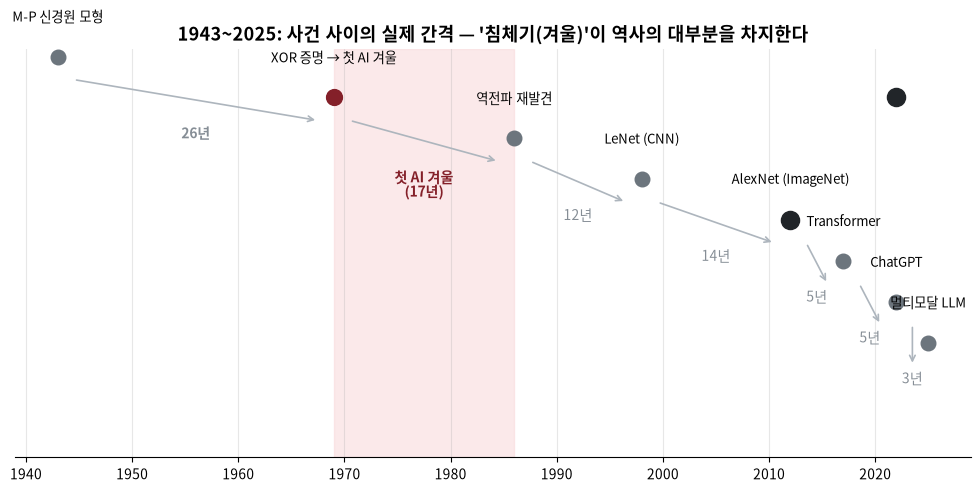

In [2]:
import matplotlib
import matplotlib.pyplot as plt
from matplotlib import font_manager

# 그래프의 한글 라벨이 깨지지 않도록 CJK 폰트 사용 (Colab에 기본 설치됨)
for _f in ["Noto Sans CJK KR", "NanumGothic", "Malgun Gothic", "AppleGothic"]:
    if any(_f.lower() == x.name.lower() for x in font_manager.fontManager.ttflist):
        plt.rcParams["font.sans-serif"] = [_f, "DejaVu Sans"]
        break
plt.rcParams["axes.unicode_minus"] = False

years = np.array([y for y, _ in events])
names = [n for _, n in events]
gaps = years[1:] - years[:-1]

fig, ax = plt.subplots(figsize=(10, 5))

# 첫 AI 겨울 (1969~1986) 배경 밴드
ax.axvspan(1969, 1986, color="#f8d7da", alpha=0.55, zorder=0)
ax.text(1977.5, 1.56, "첫 AI 겨울\n(17년)", ha="center", va="bottom",
        fontsize=10, color="#842029", fontweight="bold")

# 사건 마커: 간격이 길수록 위(높은 y)로 배치해 "침체"를 공간적으로 표현
ys = 1.0 + np.arange(len(years))[::-1] * 0.16
ax.scatter(years, ys, s=110, c="#6c757d", zorder=3)
ax.scatter([2012, 2022], [1.0 + (len(years) - 5) * 0.16, 1.0 + (len(years) - 2) * 0.16],
           s=170, c="#212529", zorder=4)
ax.scatter([1969], [1.0 + (len(years) - 2) * 0.16], s=130, c="#842029", zorder=4)

# 간격 화살표와 연수 표기
for i, g in enumerate(gaps):
    y0, y1 = ys[i], ys[i + 1]
    ax.annotate("", xy=(years[i + 1] - 1.5, y1 - 0.09), xytext=(years[i] + 1.5, y0 - 0.09),
                arrowprops=dict(arrowstyle="->", color="#adb5bd", lw=1.2))
    if g != 17:  # 1969→1986 간격은 이미 '첫 AI 겨울' 밴드에 17년으로 표시되어 있음
        ax.text((years[i] + years[i + 1]) / 2, min(y0, y1) - 0.16, f"{g}년",
                ha="center", fontsize=10, color="#868e96",
                fontweight="bold" if g == 26 else "normal")

# 사건 이름
for y, n, yy in zip(years, names, ys):
    ax.text(y, yy + 0.13, n, ha="center", va="bottom", fontsize=9.5)

ax.set_xlim(1939, 2029)
ax.set_ylim(0.55, 2.15)
ax.set_yticks([])
ax.set_xticks(range(1940, 2030, 10))
ax.set_title("1943~2025: 사건 사이의 실제 간격 — '침체기(겨울)'이 역사의 대부분을 차지한다",
             fontsize=13, fontweight="bold")
ax.spines[["top", "right", "left"]].set_visible(False)
ax.grid(axis="x", alpha=0.3)
fig.tight_layout()

# 본문의 ch01_timeline_gaps.svg로 내보내기 (Colab 등 저장소가 없는 환경에서는 건너뜀)
import os
_d, _root = os.getcwd(), None
while True:  # cwd(노트북 디렉터리)에서 repo 루트(kor/src/images 보유)를 위로 탐색
    if os.path.isdir(os.path.join(_d, "kor", "src", "images")):
        _root = _d
        break
    _p = os.path.dirname(_d)
    if _p == _d:
        break
    _d = _p
if _root:
    _out = os.path.join(_root, "kor", "src", "images", "ch01_timeline_gaps.svg")
    fig.savefig(_out, format="svg")
    print(f"본문 SVG 저장: {_out}")
else:
    print("(저장소 루트를 찾지 못해 SVG 내보내기는 건너뜀 — 이 화면의 표시만)")
plt.show()


## 3. 도구 점검 — 본문 "이번 학기 쓸 도구들" 표를 import로 검증

본문 도구 표에 등장하는 라이브러리들을 실제로 import해서 버전을 출력합니다.
이 셀이 전부 통과하면, **Block A(Chapter 2~7)에 필요한 도구(numpy, matplotlib,
pandas, scikit-learn)는 지금 이 환경에서 전부 준비되어 있다**는 뜻입니다.
PyTorch는 Chapter 9부터, Hugging Face Transformers는 Chapter 13에서
처음 손이 갈 라이브러리입니다.


In [3]:
import importlib

# (라이브러리, 본문 "언제 처음 등장") — 본문 도구 표 그대로
toolkit = [
    ("numpy",     "Chapter 2  — 모든 실습의 기본"),
    ("matplotlib","Chapter 2  — 손실 곡선, 결정경계"),
    ("pandas",    "Chapter 6  — EDA, 결측치, 그룹별 통계"),
    ("sklearn",   "Chapter 2  — 분류/회귀/클러스터링 표준 인터페이스"),
    ("torch",     "Chapter 9  — 신경망/CNN/시퀀스/VAE-GAN"),
    ("transformers", "Chapter 13 — LLM 프롬프팅 (필요 시 설치)"),
]

ok, skipped = [], []
for name, when in toolkit:
    try:
        mod = importlib.import_module(name)
        ver = getattr(mod, "__version__", "?")
        print(f"[OK]      {name:12s} {str(ver):>10s}   ({when})")
        ok.append(name)
    except ImportError:
        print(f"[MISSING] {name:12s}  {'!':>10s}   ({when})")
        skipped.append(name)

print()
block_a = {"numpy", "matplotlib", "pandas", "sklearn"}
assert block_a <= set(ok), f"Block A 도구가 부족합니다: {block_a - set(ok)}"
print("Block A(Chapter 2~7)에 필요한 도구 4종이 모두 준비되어 있습니다.")
if "torch" in ok:
    print("(PyTorch도 설치되어 있어 Chapter 9부터 바로 시작할 수 있습니다.)")
if "transformers" in skipped:
    print("(transformers는 미설치 — Chapter 13에서 `pip install transformers`로 설치하면 됩니다.)")


[OK]      numpy             2.4.6   (Chapter 2  — 모든 실습의 기본)
[OK]      matplotlib       3.11.1   (Chapter 2  — 손실 곡선, 결정경계)
[OK]      pandas            3.0.5   (Chapter 6  — EDA, 결측치, 그룹별 통계)


[OK]      sklearn           1.9.0   (Chapter 2  — 분류/회귀/클러스터링 표준 인터페이스)


[OK]      torch        2.13.0+cpu   (Chapter 9  — 신경망/CNN/시퀀스/VAE-GAN)
[MISSING] transformers           !   (Chapter 13 — LLM 프롬프팅 (필요 시 설치))

Block A(Chapter 2~7)에 필요한 도구 4종이 모두 준비되어 있습니다.
(PyTorch도 설치되어 있어 Chapter 9부터 바로 시작할 수 있습니다.)
(transformers는 미설치 — Chapter 13에서 `pip install transformers`로 설치하면 됩니다.)


## 4. 이번 절 확인 (연표가 실제로 읽히는가)

본문 "확인 문제" (a)~(c) 중 코드로 재확인할 수 있는 것을 하나 골라봅니다:
**2012년 이후 5년 주기**는 본문의 "데이터·계산의 두 축이 갖춰졌다"는
주장의 경험적 흔적입니다. 연표 데이터만으로 "2012년 이전의 평균 간격 vs
2012년 이후의 평균 간격"을 계산해 이 비대칭을 숫자로 확인합니다.


In [4]:
before = [g for (y, g) in zip(years[:-1], gaps) if y < 2012]   # 2012 이전 간격들
after  = [g for (y, g) in zip(years[:-1], gaps) if y >= 2012]  # 2012~2017, 2017~2022, 2022~2025

print("2012 이전 간격들:", before, "  평균 =", round(np.mean(before), 1), "년")
print("2012 이후 간격들:", after,  "  평균 =", round(np.mean(after), 1), "년")
assert np.mean(after) < np.mean(before)
print()
print("-> '두 축(GPU + 대규모 데이터)이 갖춰진 2012년' 이후 간격이 실제로 짧아진다.")
print("   (주의: 8개 이벤트의 간격 7개라는 매우 작은 표본 — '추세'의 감각만 갖고 넘어가자.)")


2012 이전 간격들: [np.int64(26), np.int64(17), np.int64(12), np.int64(14)]   평균 = 17.2 년
2012 이후 간격들: [np.int64(5), np.int64(5), np.int64(3)]   평균 = 4.3 년

-> '두 축(GPU + 대규모 데이터)이 갖춰진 2012년' 이후 간격이 실제로 짧아진다.
   (주의: 8개 이벤트의 간격 7개라는 매우 작은 표본 — '추세'의 감각만 갖고 넘어가자.)
